# IT2011 – Artificial Intelligence and Machine Learning

## King County House Price Prediction — Extra Trees Regressor

### Individual Model: Extra Trees Regressor

**Problem type:** Regression  
**Target:** `price`

This notebook implements an **Extra Trees Regressor** to predict house prices in the King County housing dataset.

Extra Trees is an ensemble learning method that builds multiple randomized decision trees and combines their predictions. This approach was selected because it can capture complex and non-linear relationships between housing features and price.

The model is trained using the data prepared through the corrected combined group preprocessing pipeline.Different Extra Trees configurations and hyperparameters are evaluated using cross-validation to control model complexity and identify a suitable regularized model

The final model is evaluated using appropriate regression metrics and its training and validation performance is compared to assess how well the model generalizes to unseen data.

In [ ]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Validation and model utilities
from sklearn.model_selection import KFold, cross_validate
from sklearn.base import clone

# Model
from sklearn.ensemble import ExtraTreesRegressor

# Evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# General settings
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42

print('Libraries imported successfully!')
print('Random state:', RANDOM_STATE)


Libraries imported successfully!
Random state: 42


## 1. Load the Combined-Pipeline Outputs

Upload the two CSV files produced by the corrected group pipeline:

- `final_train_processed_house_data.csv`
- `final_test_processed_house_data.csv`

These files are already separated into training and testing sets. Therefore, **no new `train_test_split()` is performed here**.


In [ ]:
# Upload the corrected train and test CSV files in Google Colab
from google.colab import files

print('Upload final_train_processed_house_data.csv and final_test_processed_house_data.csv')
uploaded = files.upload()


Upload final_train_processed_house_data.csv and final_test_processed_house_data.csv


Saving final_test_processed_house_data.csv to final_test_processed_house_data.csv
Saving final_train_processed_house_data.csv to final_train_processed_house_data.csv


In [ ]:
# Load the already-separated outputs of the corrected combined pipeline
TRAIN_FILE = 'final_train_processed_house_data.csv'
TEST_FILE = 'final_test_processed_house_data.csv'

train_df = pd.read_csv(TRAIN_FILE)
test_df = pd.read_csv(TEST_FILE)

print('Corrected combined-pipeline datasets loaded successfully!')
print('Training shape:', train_df.shape)
print('Testing shape :', test_df.shape)

print('\nSame columns in train and test:', list(train_df.columns) == list(test_df.columns))
print('Target column present:', 'price' in train_df.columns and 'price' in test_df.columns)


Corrected combined-pipeline datasets loaded successfully!
Training shape: (17290, 93)
Testing shape : (4323, 93)

Same columns in train and test: True
Target column present: True


## 2. Validate the Processed Data

The corrected combined pipeline has already performed feature engineering, log transformations, train-fitted scaling, and zipcode one-hot encoding. This section only validates the supplied model-ready datasets; it does not learn any additional preprocessing parameters.


In [ ]:
# Basic validation before modeling
print('Training missing values:', train_df.isnull().sum().sum())
print('Testing missing values :', test_df.isnull().sum().sum())
print('Training duplicate rows:', train_df.duplicated().sum())
print('Testing duplicate rows :', test_df.duplicated().sum())

print('\nTraining data types:')
print(train_df.dtypes.value_counts())

print('\nFirst five training rows:')
display(train_df.head())


Training missing values: 0
Testing missing values : 0
Training duplicate rows: 2
Testing duplicate rows : 0

Training data types:
float64    84
int64       9
Name: count, dtype: int64

First five training rows:


,bedrooms,bathrooms,floors,waterfront,view,condition,grade,sqft_basement,yr_built,lat,...,zipcode_98148,zipcode_98155,zipcode_98166,zipcode_98168,zipcode_98177,zipcode_98178,zipcode_98188,zipcode_98198,zipcode_98199,price
0,-0.395263,-0.474451,-0.919600,0,0,4,9,-0.656310,0.404001,-1.396608,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,325000.0
1,-1.468964,-1.452583,-0.919600,0,0,3,6,-0.200433,-1.430565,-0.060172,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,257000.0
2,-0.395263,-1.452583,0.001545,0,0,3,6,-0.451165,-0.988910,-0.552847,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,228500.0
3,-0.395263,0.177636,-0.919600,0,0,4,7,1.189993,0.200160,-1.193614,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,288000.0
4,-1.468964,0.503680,0.922690,0,0,3,8,0.016109,1.219364,1.040039,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,479000.0


## 3. Define Training and Testing Inputs

`price` is separated as the target. Every other column is used as a predictor. Because the group pipeline already created the split, `X_train`/`y_train` come directly from the training CSV and `X_test`/`y_test` come directly from the held-out testing CSV.


In [ ]:
# Separate predictors and target WITHOUT re-splitting the data
TARGET = 'price'

X_train = train_df.drop(columns=[TARGET]).copy()
y_train = train_df[TARGET].copy()

X_test = test_df.drop(columns=[TARGET]).copy()
y_test = test_df[TARGET].copy()

# Keep test columns in exactly the same order as training columns
X_test = X_test.reindex(columns=X_train.columns)

print('Model inputs prepared successfully!')
print('X_train:', X_train.shape)
print('y_train:', y_train.shape)
print('X_test :', X_test.shape)
print('y_test :', y_test.shape)
print('\nFeature columns aligned:', list(X_train.columns) == list(X_test.columns))
print('All predictors numeric:', X_train.select_dtypes(exclude=np.number).shape[1] == 0)


Model inputs prepared successfully!
X_train: (17290, 92)
y_train: (17290,)
X_test : (4323, 92)
y_test : (4323,)

Feature columns aligned: True
All predictors numeric: True


## Extra Trees Regressor

The Extra Trees Regressor is trained using the leakage-safe processed training data. The processed test data is kept untouched during model development and is used only for the final evaluation.

The unrestricted Extra Trees model is retained as a baseline for comparison. Since a fully grown Extra Trees model can fit the training data almost perfectly, the final model is selected from regularized configurations using cross-validation on the training set.


In [ ]:
# Libraries used for Extra Trees modelling and evaluation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import KFold, RandomizedSearchCV, cross_validate
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42
CV_FOLDS = 5


### 1. Baseline Extra Trees Model

An unrestricted Extra Trees Regressor is first trained to establish a baseline for comparison.

Because the trees are allowed to grow without explicit depth or leaf-size restrictions, the baseline model can fit the training observations extremely closely. Therefore, its training performance alone should not be used to judge how well the model will perform on unseen data.

The baseline is subsequently evaluated using 5-fold cross-validation to obtain a more reliable estimate of its generalization performance.


In [ ]:
baseline_model = ExtraTreesRegressor(
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

baseline_model.fit(X_train, y_train)
baseline_train_pred = baseline_model.predict(X_train)

baseline_train_mae = mean_absolute_error(y_train, baseline_train_pred)
baseline_train_rmse = np.sqrt(mean_squared_error(y_train, baseline_train_pred))
baseline_train_r2 = r2_score(y_train, baseline_train_pred)

print("Baseline Extra Trees - Training Performance")
print(f"MAE : {baseline_train_mae:,.2f}")
print(f"RMSE: {baseline_train_rmse:,.2f}")
print(f"R²  : {baseline_train_r2:.4f}")


Baseline Extra Trees - Training Performance
MAE : 0.01
RMSE: 0.90
R²  : 1.0000


### 2. Baseline Cross-Validation Performance

Training performance alone is not a reliable measure of generalization. Therefore, the baseline is also evaluated using 5-fold cross-validation. These results provide a fair reference for the regularized models.

The baseline achieved a 5-fold cross-validation R² of approximately 0.8889. This is lower than its near-perfect training performance, showing that the unrestricted model fits the training data more closely than unseen validation data. This difference demonstrates why cross-validation performance is more useful than training performance alone when evaluating generalization.


In [ ]:
cv = KFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE
)

scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2"
}

baseline_cv = cross_validate(
    baseline_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

baseline_cv_mae = -baseline_cv["test_MAE"].mean()
baseline_cv_rmse = -baseline_cv["test_RMSE"].mean()
baseline_cv_r2 = baseline_cv["test_R2"].mean()

print("Baseline - 5-Fold Cross-Validation")
print(f"CV MAE : {baseline_cv_mae:,.2f}")
print(f"CV RMSE: {baseline_cv_rmse:,.2f}")
print(f"CV R²  : {baseline_cv_r2:.4f}")


Baseline - 5-Fold Cross-Validation
CV MAE : 65,669.75
CV RMSE: 120,316.98
CV R²  : 0.8889


# 3.Regularized Extra Trees Hyperparameter Search

A randomized hyperparameter search is used to explore regularized Extra Trees configurations while controlling model complexity and reducing the risk of excessive overfitting.

- max_depth limits how deep each tree can grow.
- min_samples_split controls the minimum number of observations required to split a node.
- min_samples_leaf prevents leaves from being created from very small numbers of observations.
- max_features controls how many predictors are considered at each split.
- n_estimators controls the number of trees used in the ensemble.
The search uses 5-fold cross-validation and evaluates 10 randomly selected hyperparameter combinations, resulting in 50 model fits. Mean Absolute Error (MAE) is used as the optimization metric. Only the training data is used during hyperparameter tuning; the hold-out test set remains untouched until the final model evaluation.

In [ ]:
# Base estimator for the regularized search
search_estimator = ExtraTreesRegressor(
    random_state=RANDOM_STATE,
    n_jobs=1
)

# Search space for model complexity and regularization
param_distributions = {
    "n_estimators": [300, 400, 500],
    "max_depth": [15, 20, 25, 30, 35],
    "min_samples_split": [4, 6, 8, 10, 12],
    "min_samples_leaf": [2, 3, 4, 5],
    "max_features": [0.5, 0.7, 0.9, 1.0]
}

random_search = RandomizedSearchCV(
    estimator=search_estimator,
    param_distributions=param_distributions,
    n_iter=10,
    scoring="neg_mean_absolute_error",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

random_search.fit(X_train, y_train)

print("Best Regularized Parameters")
for parameter, value in random_search.best_params_.items():
    print(f"{parameter}: {value}")

print(f"Best 5-fold CV MAE: {-random_search.best_score_:,.2f}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Regularized Parameters
n_estimators: 500
min_samples_split: 6
min_samples_leaf: 3
max_features: 0.9
max_depth: 30
Best 5-fold CV MAE: 66,585.10


### 4. Hyperparameter Search Results

The best search results are displayed below. The table includes both training and validation MAE so that the difference between fitting performance and cross-validation performance can be inspected before the final model is evaluated.

The objective of this search is to identify the regularized configuration with the lowest validation MAE among the tested configurations, rather than selecting a model based on training performance alone.


In [ ]:
search_results = pd.DataFrame(random_search.cv_results_)

search_summary = pd.DataFrame({
    "Rank": search_results["rank_test_score"],
    "CV Train MAE": -search_results["mean_train_score"],
    "CV Validation MAE": -search_results["mean_test_score"],
    "max_depth": search_results["param_max_depth"],
    "min_samples_split": search_results["param_min_samples_split"],
    "min_samples_leaf": search_results["param_min_samples_leaf"],
    "max_features": search_results["param_max_features"],
    "n_estimators": search_results["param_n_estimators"]
})

search_summary = search_summary.sort_values("Rank").head(10).reset_index(drop=True)

display(search_summary.round({
    "CV Train MAE": 2,
    "CV Validation MAE": 2
}))


,Rank,CV Train MAE,CV Validation MAE,max_depth,min_samples_split,min_samples_leaf,max_features,n_estimators
0,1,29351.37,66585.10,30,6,3,0.9,500
1,2,29292.62,66589.88,35,4,3,0.9,300
2,3,38918.77,67181.91,35,10,3,0.7,300
3,4,43337.93,67810.77,35,12,4,0.9,400
4,5,44845.58,68239.87,35,6,5,0.9,500
5,6,44871.74,68271.34,35,4,5,0.9,400
6,7,45885.85,68586.49,20,4,5,1.0,400
7,8,44568.87,68623.96,20,4,4,0.7,300
8,9,42149.27,69561.13,15,4,2,0.9,400
9,10,54963.35,71055.55,15,12,3,0.7,300


### 5. Selected Regularized Model

The best regularized configuration is selected using the lowest 5-fold cross-validation MAE among the tested regularized configurations. The unrestricted baseline is retained separately as a reference. The purpose of selecting a regularized configuration is to control model complexity rather than simply selecting the model with the highest training performance.


In [ ]:
selected_model = random_search.best_estimator_
selected_name = "Regularized Extra Trees"

print("Selected model:", selected_name)
print("Selection criterion: Lowest 5-fold CV MAE among regularized configurations")
print()
print(selected_model)


Selected model: Regularized Extra Trees
Selection criterion: Lowest 5-fold CV MAE among regularized configurations

ExtraTreesRegressor(max_depth=30, max_features=0.9, min_samples_leaf=3,
                    min_samples_split=6, n_estimators=500, n_jobs=1,
                    random_state=42)


### 6. Cross-Validation of the Selected Model

The selected configuration is evaluated using MAE, RMSE, and R² across the same five training folds.

The selected model achieved a 5-fold cross-validation R² of approximately 0.8784. This indicates that the model explains around 87.8% of the variation in the target across unseen validation folds. Cross-validation provides an estimate of the performance that can be expected when the model is applied to unseen observations.



In [ ]:
selected_cv = cross_validate(
    selected_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

selected_cv_mae = -selected_cv["test_MAE"].mean()
selected_cv_rmse = -selected_cv["test_RMSE"].mean()
selected_cv_r2 = selected_cv["test_R2"].mean()

cv_comparison = pd.DataFrame({
    "Model": ["Baseline Extra Trees", "Selected Regularized Extra Trees"],
    "CV MAE": [baseline_cv_mae, selected_cv_mae],
    "CV RMSE": [baseline_cv_rmse, selected_cv_rmse],
    "CV R²": [baseline_cv_r2, selected_cv_r2]
})

display(cv_comparison.round({
    "CV MAE": 2,
    "CV RMSE": 2,
    "CV R²": 4
}))


,Model,CV MAE,CV RMSE,CV R²
0,Baseline Extra Trees,65669.75,120316.98,0.8889
1,Selected Regularized Extra Trees,66585.10,126026.71,0.8784


### 7. Fit the Final Model on the Full Training Set

After the regularized configuration has been selected using cross-validation, it is fitted using the complete training dataset.

After fitting, the model achieved a training R² of approximately 0.9756, showing that it captures a large proportion of the variation in the training data. However, this score is not considered alone because high training performance can occur when a model overfits. It is therefore compared with cross-validation and final test performance.


In [ ]:
selected_model.fit(X_train, y_train)

train_pred = selected_model.predict(X_train)

train_mae = mean_absolute_error(y_train, train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
train_r2 = r2_score(y_train, train_pred)

print("Final Model - Training Performance")
print(f"MAE : {train_mae:,.2f}")
print(f"RMSE: {train_rmse:,.2f}")
print(f"R²  : {train_r2:.4f}")


Final Model - Training Performance
MAE : 28,904.58
RMSE: 56,492.47
R²  : 0.9756


### 8. Final Evaluation on the Held-Out Test Set

The test data is used only at this stage. MAE, RMSE, and R² are calculated to measure how well the selected model generalizes to unseen observations.


The final model achieved a test R² of 0.8720, meaning that approximately 87.2% of the variation in house prices in the held-out test data is explained by the model.
The MAE of approximately 70,106 represents the average absolute difference between the predicted and actual house prices.
The RMSE of approximately 139,127 is considerably higher than the MAE. Since RMSE gives greater weight to large errors, this suggests that some observations have substantially larger prediction errors.
Because the test dataset was not used during training or hyperparameter selection, these results provide the final estimate of the model's performance on unseen data.

In [ ]:
test_pred = selected_model.predict(X_test)

final_mae = mean_absolute_error(y_test, test_pred)
final_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
final_r2 = r2_score(y_test, test_pred)

print("Final Test Performance")
print(f"MAE : {final_mae:,.2f}")
print(f"RMSE: {final_rmse:,.2f}")
print(f"R²  : {final_r2:.4f}")


Final Test Performance
MAE : 70,105.99
RMSE: 139,126.72
R²  : 0.8720


### 9. Training vs Testing Performance

Training and testing performance are compared to identify possible overfitting.
The R² generalization gap is calculated as:

Training R² − Testing R²

The final model achieved a training R² of 0.9756 and a test R² of 0.8720, resulting in a gap of approximately 0.1036, or 10.36 percentage points.

This indicates that some overfitting remains because the model performs better on the observations used for training than on unseen test observations.

However, the 5-fold cross-validation R² of 0.8784 is very close to the final test R² of 0.8720. This shows that the performance observed on the held-out test set is consistent with the performance obtained across the validation folds.
Therefore, the model demonstrates reasonably stable performance on unseen data, although some overfitting remains.


In [ ]:
performance_comparison = pd.DataFrame({
    "Dataset": ["Training", "Testing"],
    "MAE": [train_mae, final_mae],
    "RMSE": [train_rmse, final_rmse],
    "R²": [train_r2, final_r2]
})

r2_gap = train_r2 - final_r2

display(performance_comparison.round({
    "MAE": 2,
    "RMSE": 2,
    "R²": 4
}))

print(f"R² generalization gap: {r2_gap:.4f}")
print(f"R² gap in percentage points: {r2_gap * 100:.2f}")


,Dataset,MAE,RMSE,R²
0,Training,28904.58,56492.47,0.9756
1,Testing,70105.99,139126.72,0.8720


R² generalization gap: 0.1036
R² gap in percentage points: 10.36


In [ ]:
# General interpretation of the train-test difference
if r2_gap <= 0.05:
    gap_comment = "The model has a relatively small train-test gap."
elif r2_gap <= 0.10:
    gap_comment = "The model has a moderate train-test gap."
else:
    gap_comment = "The model still shows a noticeable train-test gap."

print(gap_comment)
print("The cross-validation results are also considered when judging generalization.")


The model still shows a noticeable train-test gap.
The cross-validation results are also considered when judging generalization.


### 10. Actual vs Predicted House Prices

The following plot compares actual test-set house prices with the prices predicted by the final Extra Trees model.

Predictions closer to the diagonal reference line represent smaller prediction errors. The plot can therefore be used to visually inspect how closely the predicted house prices match the actual values. Points further away from the reference line represent observations with larger prediction errors.

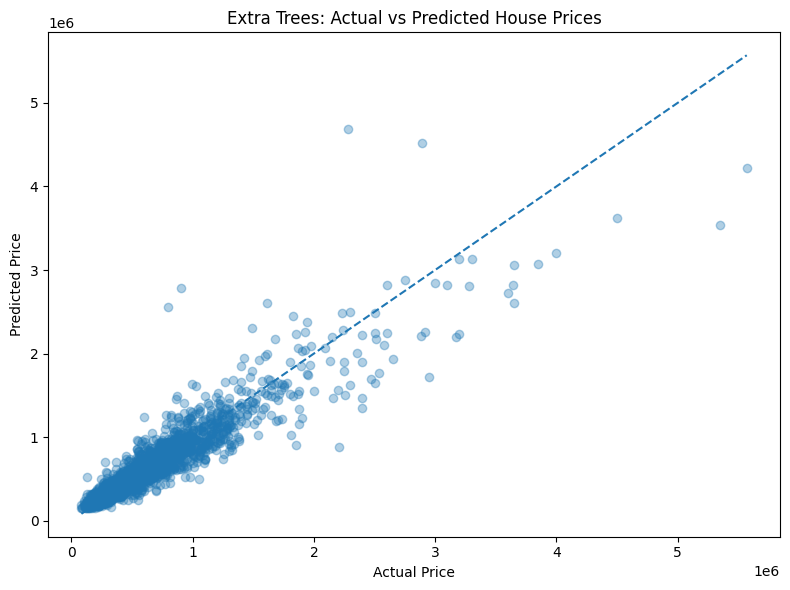

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, test_pred, alpha=0.35)

line_min = min(y_test.min(), test_pred.min())
line_max = max(y_test.max(), test_pred.max())
plt.plot([line_min, line_max], [line_min, line_max], linestyle="--")

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Extra Trees: Actual vs Predicted House Prices")
plt.tight_layout()
plt.show()


### 11. Feature Importance

The 15 predictors with the highest Extra Trees feature importance values are shown below. Feature importance indicates how strongly each predictor contributes to the model's predictions. However, these values represent predictive importance and should not be interpreted as evidence that a feature directly causes changes in house prices.


,Feature,Importance
0,grade,0.234663
1,sqft_living_log,0.192567
2,lat,0.120431
3,sqft_living15,0.071119
4,sqft_above_log,0.063988
5,view,0.042135
6,bathrooms,0.039231
7,waterfront,0.035573
8,zipcode_98004,0.029740
9,long,0.024748


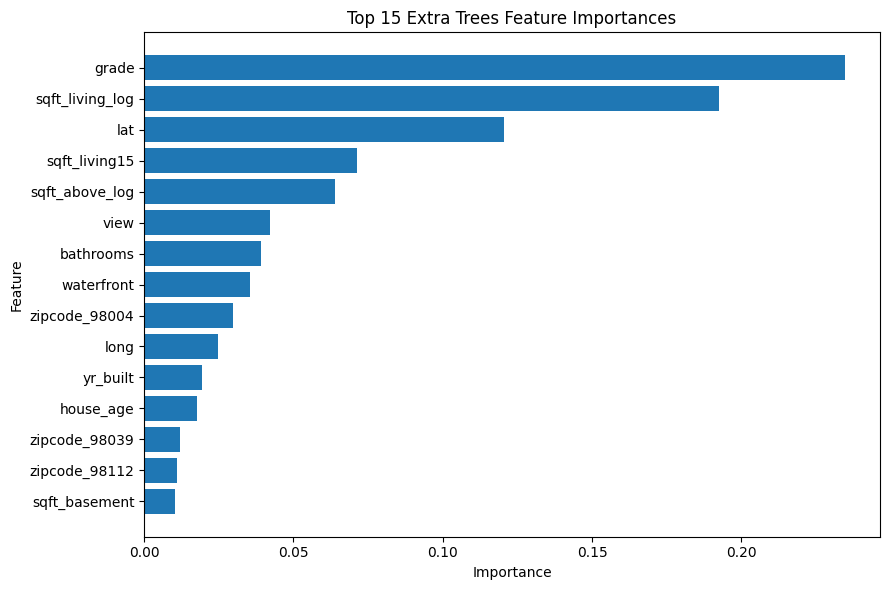

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": selected_model.feature_importances_
}).sort_values("Importance", ascending=False)

display(feature_importance.head(15).reset_index(drop=True))

top_features = feature_importance.head(15).sort_values("Importance")

plt.figure(figsize=(9, 6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Extra Trees Feature Importances")
plt.tight_layout()
plt.show()


### 12. Baseline vs Regularized Model

The baseline and selected regularized model are compared using 5-fold cross-validation.

The unrestricted baseline achieved a CV R² of approximately 0.8889, while the selected regularized model achieved approximately 0.8784. The baseline also achieved a slightly lower CV MAE.

Therefore, regularization did not improve cross-validation predictive performance in this experiment. Instead, regularization was introduced to constrain the complexity of the Extra Trees model and reduce its tendency to fit the training observations extremely closely.

This represents a small trade-off in validation performance in exchange for greater control over model complexity. Therefore, the regularized model should not be described as outperforming the baseline in cross-validation.

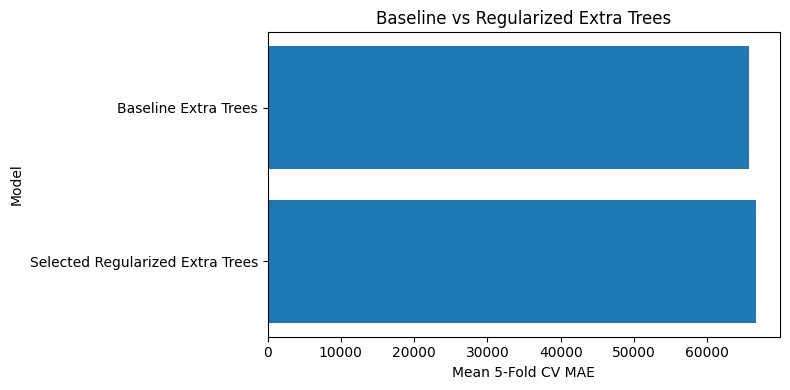

In [ ]:
comparison_plot = cv_comparison.sort_values("CV MAE", ascending=False)

plt.figure(figsize=(8, 4))
plt.barh(comparison_plot["Model"], comparison_plot["CV MAE"])
plt.xlabel("Mean 5-Fold CV MAE")
plt.ylabel("Model")
plt.title("Baseline vs Regularized Extra Trees")
plt.tight_layout()
plt.show()


## Final Model Conclusion

The unrestricted Extra Trees model was first evaluated as a baseline. Its near-perfect training performance demonstrated the high fitting capacity of an unrestricted tree ensemble.

RandomizedSearchCV with 5-fold cross-validation was then used to explore regularized Extra Trees configurations that constrained model complexity.
The final regularized model achieved a training R² of 0.9756, a 5-fold cross-validation R² of 0.8784, and a held-out test R² of 0.8720.

The difference between training and test performance indicates that some overfitting remains. However, the close agreement between the cross-validation R² of 0.8784 and test R² of 0.8720 indicates that the model's performance on unseen observations is reasonably consistent.

The final test MAE was approximately 70,106, while the RMSE was approximately 139,127. The higher RMSE suggests that some observations have considerably larger prediction errors.

Overall, the final Extra Trees model demonstrates good predictive performance on unseen data, although further regularization, hyperparameter exploration, or feature engineering could potentially reduce the remaining overfitting.


In [ ]:
print("FINAL EXTRA TREES SUMMARY")
print("-" * 50)
print("Model           : Regularized Extra Trees")
print(f"CV MAE          : {selected_cv_mae:,.2f}")
print(f"CV RMSE         : {selected_cv_rmse:,.2f}")
print(f"CV R²           : {selected_cv_r2:.4f}")
print()
print(f"Training R²     : {train_r2:.4f}")
print(f"Test MAE        : {final_mae:,.2f}")
print(f"Test RMSE       : {final_rmse:,.2f}")
print(f"Test R²         : {final_r2:.4f}")
print(f"Train-Test Gap  : {r2_gap:.4f} ({r2_gap * 100:.2f} percentage points)")
print()
print("Best parameters:")
for parameter, value in random_search.best_params_.items():
    print(f"  {parameter}: {value}")


FINAL EXTRA TREES SUMMARY
--------------------------------------------------
Model           : Regularized Extra Trees
CV MAE          : 66,585.10
CV RMSE         : 126,026.71
CV R²           : 0.8784

Training R²     : 0.9756
Test MAE        : 70,105.99
Test RMSE       : 139,126.72
Test R²         : 0.8720
Train-Test Gap  : 0.1036 (10.36 percentage points)

Best parameters:
  n_estimators: 500
  min_samples_split: 6
  min_samples_leaf: 3
  max_features: 0.9
  max_depth: 30


# Extra Trees Regressor – Evaluation Summary

## 1. Model Suitability

The **Extra Trees Regressor** was selected for the King County house price prediction problem because `price` is a continuous target variable, making this a regression problem.

Extra Trees is an ensemble learning algorithm that builds multiple randomized decision trees and combines their predictions. It is suitable for house price prediction because relationships between house characteristics and price can be complex and non-linear. The model can capture these relationships and interactions between features without assuming a simple linear relationship.

---

## 2. Data and Preprocessing

The model uses the processed training and testing datasets produced by the corrected combined group preprocessing pipeline.

The combined pipeline already performed feature engineering, log transformations, scaling, zipcode one-hot encoding, and the train-test split.

The final datasets contained:

- Training observations: **17,290**
- Testing observations: **4,323**
- Predictor features: **92**
- Target variable: **`price`**

The train and test datasets were kept separate throughout model development. No additional train-test split, scaling, or encoding was performed inside the Extra Trees notebook.

This ensures that the held-out test set remains unseen during model training and hyperparameter tuning.

---

## 3. Model Implementation

The Extra Trees model was implemented using Scikit-learn's:

`ExtraTreesRegressor`

The main libraries and functions used were:

- `ExtraTreesRegressor` – building the regression model
- `RandomizedSearchCV` – hyperparameter tuning
- `KFold` – 5-fold cross-validation
- `cross_validate` – evaluating models across the validation folds
- `mean_absolute_error` – calculating MAE
- `mean_squared_error` – calculating RMSE
- `r2_score` – calculating R²

A fixed `random_state = 42` was used to make the results reproducible.

---

## 4. Baseline Extra Trees Model

An unrestricted Extra Trees model was first trained as a baseline using:

- `n_estimators = 300`
- `random_state = 42`
- `n_jobs = -1`

The baseline training performance was:

- **Training MAE:** 0.01
- **Training RMSE:** 0.90
- **Training R²:** 1.0000

The almost perfect training performance indicates that the unrestricted Extra Trees model fits the training observations extremely closely. Therefore, training performance alone was not used to select the final model.

The baseline was also evaluated using 5-fold cross-validation:

- **CV MAE:** 65,669.75
- **CV RMSE:** 120,316.98
- **CV R²:** 0.8889

The large difference between the almost perfect training performance and cross-validation performance shows why validation is important when evaluating this model.

---

## 5. Hyperparameter Tuning

The Extra Trees model was tuned using **RandomizedSearchCV**.

The following hyperparameters were explored:

- `n_estimators`: **300, 400, 500**
- `max_depth`: **15, 20, 25, 30, 35**
- `min_samples_split`: **4, 6, 8, 10, 12**
- `min_samples_leaf`: **2, 3, 4, 5**
- `max_features`: **0.5, 0.7, 0.9, 1.0**

These parameters were selected because they control the number of trees, tree complexity, minimum observations required for splitting and leaf nodes, and the number of features considered during splitting.

RandomizedSearchCV evaluated **10 different hyperparameter configurations** using **5-fold cross-validation**.

Therefore:

**10 configurations × 5 folds = 50 model fits**

The optimization metric used during the search was **MAE (Mean Absolute Error)**.

Only the training data was used during hyperparameter tuning. The held-out test set was not used to select the model.

---

## 6. Best Hyperparameter Configuration

The best regularized configuration identified by RandomizedSearchCV was:

- `n_estimators = 500`
- `max_depth = 30`
- `min_samples_split = 6`
- `min_samples_leaf = 3`
- `max_features = 0.9`
- `random_state = 42`

This configuration was selected because it achieved the **lowest 5-fold cross-validation MAE among the regularized configurations**.

Its cross-validation performance was:

- **CV MAE:** 66,585.10
- **CV RMSE:** 126,026.71
- **CV R²:** 0.8784

---

## 7. Evaluation Metrics

Three regression metrics were used to evaluate the model:

### R²

R² measures how much of the variation in house prices is explained by the model. A value closer to 1 indicates stronger predictive performance.

### MAE – Mean Absolute Error

MAE measures the average absolute difference between the actual and predicted house prices.

It is useful because it provides an easily interpretable measure of the model's average prediction error in the same unit as house price.

### RMSE – Root Mean Squared Error

RMSE measures prediction error while giving greater weight to larger errors.

This is useful for house price prediction because very large prediction errors are important and should have a greater effect on the evaluation.

Therefore, a stronger regression model generally has a **higher R² and lower MAE and RMSE**.

---

## 8. Validation Method

**5-fold cross-validation** was used.

The training dataset was divided into five folds. During each validation round, the model was trained using four folds and validated using the remaining fold. This process was repeated so that every fold was used for validation.

The folds were shuffled and `random_state = 42` was used for reproducibility.

Cross-validation was used because evaluating several folds provides a more reliable estimate of model performance than relying on a single training score.

The held-out test dataset remained separate and was only used for the final evaluation.

---

## 9. Comparison of Model Variations

A total of **10 regularized Extra Trees configurations** were evaluated during RandomizedSearchCV.

Their cross-validation MAE values ranged from approximately **66,585 to 71,056**.

The best regularized configuration achieved:

**CV MAE = 66,585.10**

The unrestricted baseline achieved:

**CV MAE = 65,669.75**

Therefore, the unrestricted baseline actually produced a slightly lower cross-validation MAE than the selected regularized model.

However, the unrestricted baseline also achieved an almost perfect training R² of **1.0000**, showing that it fitted the training observations extremely closely.

The purpose of the regularized model was therefore to control model complexity rather than simply selecting the model with the highest training performance.

---

## 10. Final Training and Test Performance

After selecting the best regularized configuration, it was fitted using the complete training dataset.

### Training Performance

- **MAE:** 28,904.58
- **RMSE:** 56,492.47
- **R²:** 0.9756

### Held-Out Test Performance

- **MAE:** 70,105.99
- **RMSE:** 139,126.72
- **R²:** 0.8720

The test R² of **0.8720** means that the final Extra Trees model explains approximately **87.2% of the variation in house prices in the held-out test data**.

---

## 11. Overfitting and Generalization

The final regularized model achieved:

- **Training R²:** 0.9756
- **Test R²:** 0.8720
- **Train-test R² gap:** 0.1036
- **Difference:** approximately **10.36 percentage points**

The training performance is noticeably higher than the test performance. Therefore, the model still shows **some evidence of overfitting**.

However, the model still achieves a strong test R² of **0.8720**, meaning that it retains substantial predictive ability on unseen data.

The 5-fold cross-validation R² of **0.8784** is also close to the final test R² of **0.8720**. This consistency between cross-validation and held-out test performance provides evidence that the model's unseen-data performance is reasonably stable.

Therefore, the model can be described as having **good predictive performance with some remaining overfitting**.

---

## 12. Feature Importance

Extra Trees also provides feature importance values, which were used to identify the predictors that contributed most strongly to the model.

The most important features included:

1. `grade`
2. `sqft_living_log`
3. `lat`
4. `sqft_living15`
5. `sqft_above_log`
6. `view`
7. `bathrooms`
8. `waterfront`

The most influential feature was **`grade`**, followed by **`sqft_living_log`**.

This indicates that property quality, living area, location, and related housing characteristics played important roles in the model's house price predictions.

---

## 13. Limitations

The Extra Trees model has several limitations:

- The model still shows a noticeable difference between training and test performance, indicating some remaining overfitting.
- Extra Trees is less interpretable than a simple model such as Linear Regression because predictions are generated by combining many randomized decision trees.
- Increasing the number of trees and performing hyperparameter searches increases computational cost.
- Only 10 randomly selected hyperparameter combinations were evaluated, so better combinations may exist outside the tested configurations.
- Feature importance shows which variables influence the model but does not directly explain the direction of their effect on house prices.

---

## 14. Possible Improvements

Possible improvements include:

- Testing a larger number of hyperparameter combinations.
- Expanding the ranges used in RandomizedSearchCV.
- Applying stronger regularization to further reduce the train-test performance gap.
- Performing additional feature engineering or feature selection.
- Comparing the Extra Trees model with the other individual models developed by the group to determine which model provides the best overall unseen-data performance.

---

## 15. Final Conclusion

The Extra Trees Regressor was successfully implemented for King County house price prediction.

An unrestricted Extra Trees model was first used as a baseline, followed by **10 regularized model configurations evaluated through 5-fold cross-validation**, resulting in **50 model fits** during the randomized hyperparameter search.

The selected model used **500 trees, a maximum depth of 30, minimum split size of 6, minimum leaf size of 3, and `max_features = 0.9`**.

The final model achieved a **test R² of 0.8720, MAE of 70,105.99, and RMSE of 139,126.72**.

Although the train-test R² gap of **10.36 percentage points** indicates some remaining overfitting, the cross-validation R² of **0.8784** and test R² of **0.8720** are very similar. This indicates that the model provides strong and reasonably consistent performance on unseen data.

The Extra Trees model can therefore be compared with the other individual models developed by the group when selecting the overall best model.
